In [43]:

import numpy as np
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

import healpy as hp

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import LambdaCDM

In [44]:
# Set default font size
mpl.rcParams['font.size'] = 12

## Process the Neronov-Semikoz catalog

In [45]:
# load NS catalog
ns_catalog = pd.read_csv("NS_total.csv", index_col=0)

In [46]:
ns_catalog = ns_catalog[ns_catalog["z"] < 0.51]
ns_catalog.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table
2,RX J0022.0+0006,5.515,0.113,5,9,1,1.66±0.12,0.306,BLL,NaN,2
3,SHBL J001355.9-185406,3.480,-18.912,2,2,1,1.9±0.08,0.095,BLL,E,1
5,PMN J0039-2220,9.778,-22.328,1,4,1,1.78±0.09,0.064,BLL,NaN,3
6,RBS 0723,131.812,11.569,2,2,0,1.77±0.06,0.198,BLL,E,1
8,1RXS J005117.7-624154,12.824,-62.704,2,5,1,1.77±0.02,0.156,BLL,NaN,2


In [47]:
MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg')
theta_MW, phi_MW = np.pi/2 - MW_plane.galactic.b.rad, MW_plane.galactic.l.rad

EQ_plane = SkyCoord(ra=np.linspace(0, 360, 100), dec=0.0, frame='icrs', unit='deg')
theta_EQ, phi_EQ = np.pi/2 - MW_plane.galactic.b.rad, MW_plane.galactic.l.rad

/tmp/ipykernel_564567/1746922977.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


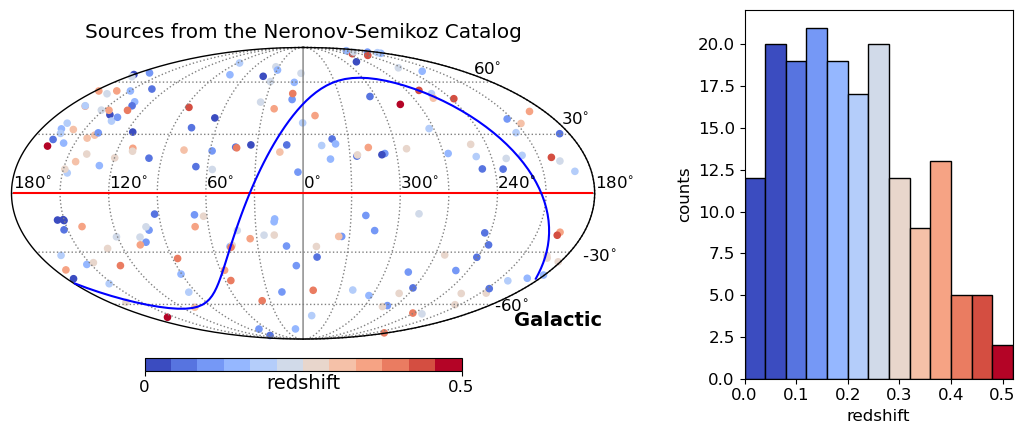

In [48]:
fig = plt.figure(figsize=(12, 4.5))
cmap = plt.get_cmap('coolwarm', lut=12)

gs = GridSpec(ncols=2, nrows=1, figure=fig, width_ratios=[3, 1])

ax = fig.add_subplot(gs[1])

bins = np.arange(0, 0.53, 0.04)
for i, b in enumerate(bins[:-1]):
    hist_cor = ns_catalog[(ns_catalog['z'] < bins[i+1]) * (ns_catalog['z'] > bins[i])]
    histp = sns.histplot(hist_cor['z'], bins=[bins[i], bins[i+1]], edgecolor='black', facecolor=cmap(bins[i]/0.52))
ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])

ax.set_xlabel("redshift")
ax.set_xlim(0, 0.52)
ax.set_ylabel("counts")

ax2 = fig.add_subplot(gs[0])
plt.sca(ax2)                     # Set Current Axis to the one we just made
bg = np.ones(hp.nside2npix(128)) * hp.UNSEEN
hp.mollview(
    bg,
    min=0.0, max=0.5, 
    coord=['C', 'G'],
    cmap=cmap,
    badcolor='white',
    cbar=True,
    unit='redshift',
    title=f"Sources from the Neronov-Semikoz Catalog",
    sub=None,
    hold=True
)
hp.projscatter(np.pi/2 - np.deg2rad(ns_catalog["Dec"]), np.deg2rad(ns_catalog["RA"]), coord='C',
               s=20, c=ns_catalog['z'], cmap=cmap, vmin=0.0, vmax=0.5)
hp.graticule(color='gray')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='C')

plt.tight_layout()
# plt.savefig("lss-NS.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

## Combine the catalog with the LSS

In [49]:
import os

ovd_files = os.listdir('./overdensity')
z_start, z_end = [float(f[4:7])/100 for f in ovd_files], [float(f[8:11])/100 for f in ovd_files]

zbins = z_start.copy()
zbins.append(z_end[-1])

maps = [np.load(f"./overdensity/{f}") for f in ovd_files]

In [50]:
ns_catalog["mapclass"] = np.digitize(ns_catalog["z"], zbins, right=True)

In [51]:
nside = 128
npix = hp.nside2npix(nside)

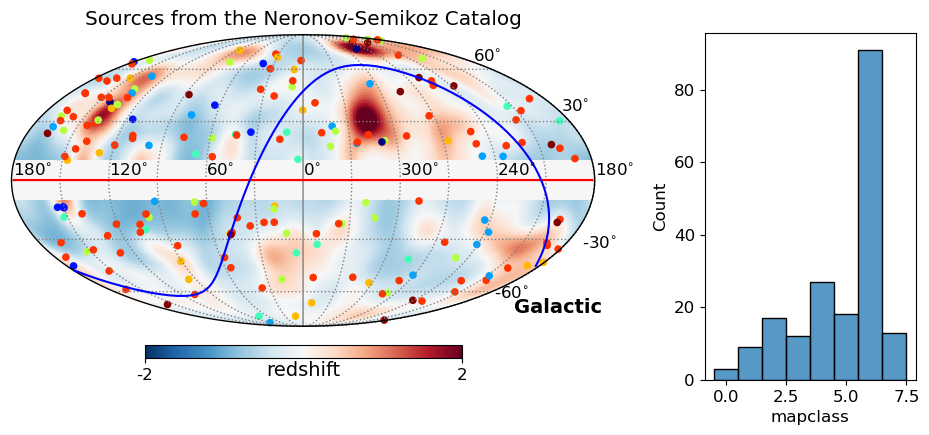

In [52]:
fig = plt.figure(figsize=(12, 4.5))
cmap = plt.get_cmap('jet', lut=8)

gs = GridSpec(ncols=2, nrows=1, figure=fig, width_ratios=[3, 1])

ax = fig.add_subplot(gs[1])
histp = sns.histplot(ns_catalog['mapclass'], binwidth=1, binrange=[-0.5, 7.5])

ax2 = fig.add_subplot(gs[0])
plt.sca(ax2)                     # Set Current Axis to the one we just made
hp.mollview(
    maps[0],
    min=-2.0, max=2.0, 
    coord=['C', 'G'],
    cmap='RdBu_r',
    badcolor='white',
    cbar=True,
    unit='redshift',
    title=f"Sources from the Neronov-Semikoz Catalog",
    sub=None,
    hold=True
)
hp.projscatter(np.pi/2 - np.deg2rad(ns_catalog["Dec"]), np.deg2rad(ns_catalog["RA"]), coord='C',
               s=20, c=ns_catalog['mapclass'], cmap=cmap, vmin=0, vmax=7)
hp.graticule(color='gray')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='C')

# plt.savefig("lss-NS.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

In [53]:
# Map pix
ns_catalog["mappix"] = hp.ang2pix(nside, np.pi/2 - np.deg2rad(ns_catalog["Dec"]), np.deg2rad(ns_catalog["RA"]))
ns_catalog.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,mapclass,mappix
2,RX J0022.0+0006,5.515,0.113,5,9,1,1.66±0.12,0.306,BLL,NaN,2,6,97544
3,SHBL J001355.9-185406,3.480,-18.912,2,2,1,1.9±0.08,0.095,BLL,E,1,3,130309
5,PMN J0039-2220,9.778,-22.328,1,4,1,1.78±0.09,0.064,BLL,NaN,3,2,135438
6,RBS 0723,131.812,11.569,2,2,0,1.77±0.06,0.198,BLL,E,1,6,78779
8,1RXS J005117.7-624154,12.824,-62.704,2,5,1,1.77±0.02,0.156,BLL,NaN,2,5,185518


0


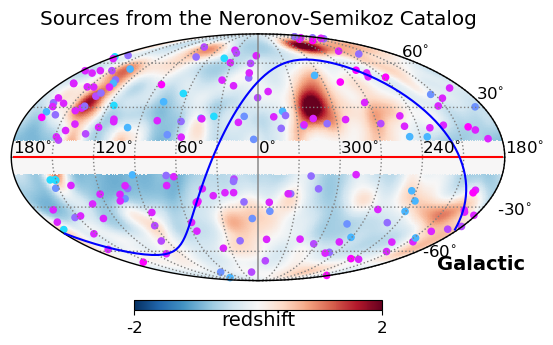

1


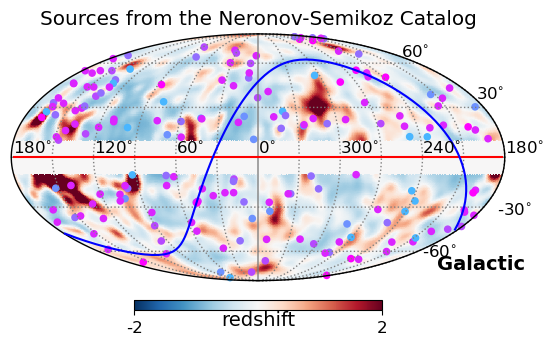

2


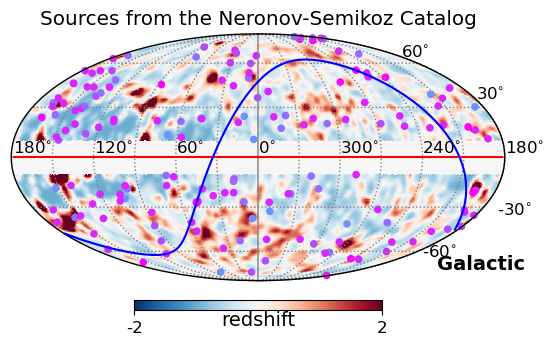

3


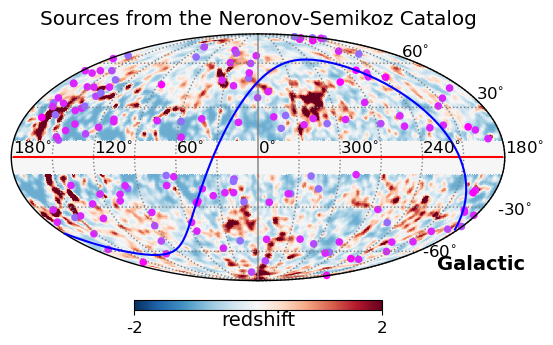

4


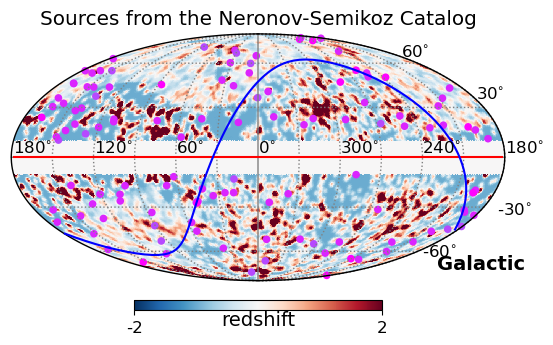

5


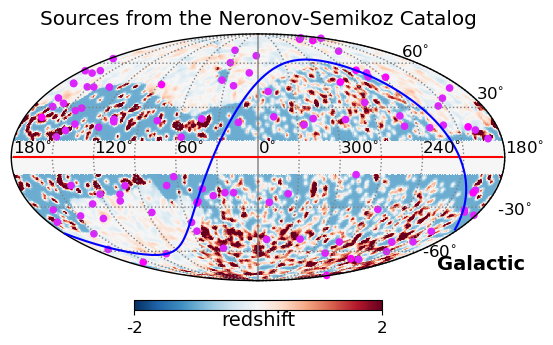

In [54]:
# Show NS sources on the overdensity maps

for i, b in enumerate(z_end):
    print(i)
    ns_catalog_i = ns_catalog[ns_catalog["mapclass"] > i]
    hp.mollview(
        maps[i],
        min=-2.0, max=2.0, 
        coord=['C', 'G'],
        cmap='RdBu_r',
        badcolor='white',
        cbar=True,
        unit='redshift',
        title=f"Sources from the Neronov-Semikoz Catalog",
        sub=None,
        hold=True
    )
    hp.projscatter(np.pi/2 - np.deg2rad(ns_catalog_i["Dec"]), np.deg2rad(ns_catalog_i["RA"]), coord='C',
                s=20, c=ns_catalog_i['mapclass'], cmap='cool', vmin=0, vmax=7)
    hp.graticule(color='gray')

    for l in range(0, 360, 60):
        hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
        if l == 180:
            hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
            
    for m in range(-60, 90, 30):
        if m == 0:
            continue
        hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                    f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

    hp.projplot(theta_MW, phi_MW, color='red', coord='G')
    hp.projplot(theta_EQ, phi_EQ, color='blue', coord='C')

    plt.show()

## Calculate cumulative overdensity

In [83]:
ns_catalog["zweight"] = 1.0
ns_catalog["mapval"] = 0.0
weights = np.array(z_end) - np.array(z_start)
weights[-1] = 0.00
print(weights)
cs_weights = z_end
print(cs_weights)

for i in range(len(z_end)):
    good_src  = ns_catalog["mapclass"] > i
    mapvals = maps[i][ns_catalog["mappix"]]
    ns_catalog["mapval"] += mapvals * good_src * weights[i]
    ns_catalog.loc[good_src, "zweight"] = cs_weights[i]

# normalization
ns_catalog["mapval"] /= ns_catalog["zweight"]
ns_catalog.head()

[0.03 0.03 0.03 0.04 0.04 0.  ]
[0.04, 0.07, 0.1, 0.14, 0.18, 0.4]


,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,mapclass,mappix,zweight,mapval
2,RX J0022.0+0006,5.515,0.113,5,9,1,1.66±0.12,0.306,BLL,NaN,2,6,97544,0.40,0.070264
3,SHBL J001355.9-185406,3.480,-18.912,2,2,1,1.9±0.08,0.095,BLL,E,1,3,130309,0.10,0.014917
5,PMN J0039-2220,9.778,-22.328,1,4,1,1.78±0.09,0.064,BLL,NaN,3,2,135438,0.07,0.117959
6,RBS 0723,131.812,11.569,2,2,0,1.77±0.06,0.198,BLL,E,1,6,78779,0.40,-0.021878
8,1RXS J005117.7-624154,12.824,-62.704,2,5,1,1.77±0.02,0.156,BLL,NaN,2,5,185518,0.18,0.061890


In [84]:
ns_extr = ns_catalog[ns_catalog["HSP"] == "E"]

(array([ 2.,  3.,  2., 10., 10., 12.,  3.,  6.,  3.,  4.]),
 array([-0.61347393, -0.48495143, -0.35642893, -0.22790643, -0.09938393,
         0.02913857,  0.15766107,  0.28618357,  0.41470607,  0.54322857,
         0.67175107]),
 <BarContainer object of 10 artists>)

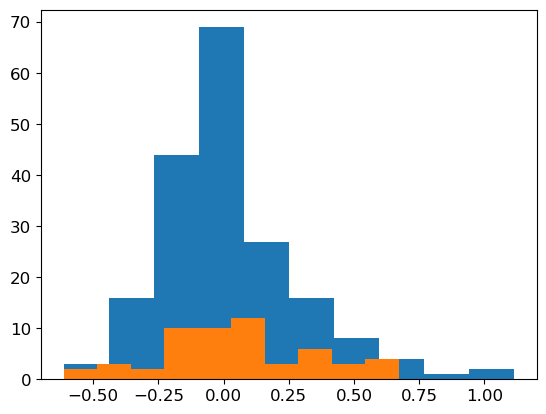

In [85]:
plt.hist(ns_catalog["mapval"])
plt.hist(ns_extr["mapval"])

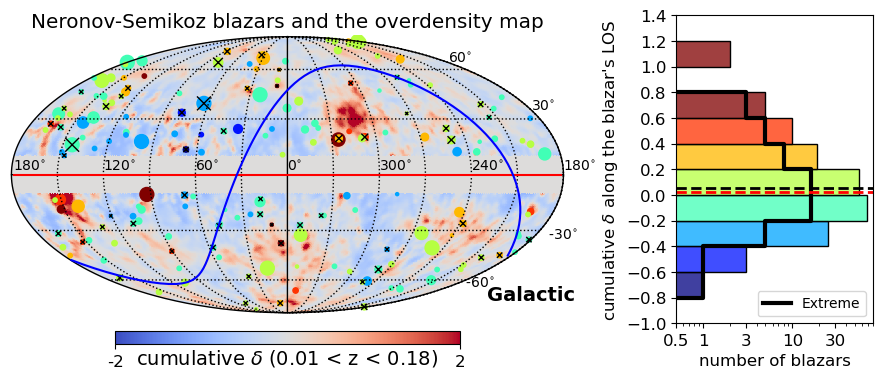

In [86]:
fig = plt.figure(figsize=(12, 4))
gs = GridSpec(1, 2, figure=fig, width_ratios=[7, 2], wspace=0.1)

ax =  fig.add_subplot(gs[0])
plt.sca(ax)
hp.mollview(np.average(np.array(maps)[:-1], axis=0), coord=['C', 'G'], cmap='coolwarm',
            title="Neronov-Semikoz blazars and the overdensity map",
            min=-2, max=2, cbar=True,
            unit=r'cumulative $\delta$ (0.01 < z < 0.18)',
            notext=False, sub=None, hold=True, margins=[0, -0.10, 0, 0.05])

hp.graticule(color='black')

size = np.clip(5 * ns_catalog["N_100"], a_min=0.0, a_max=100.0)

# ALL BLAZARS
cmap = plt.get_cmap("jet", lut=8)
p = hp.projscatter(np.pi/2 - np.deg2rad(ns_catalog["Dec"]), np.deg2rad(ns_catalog["RA"]), coord='C',
               s=size, c=ns_catalog['mapval'], cmap=cmap, vmin=-0.8, vmax=0.8)
# plt.colorbar(p)

# EXTREME
size = np.clip(5 * ns_extr["N_100"], a_min=0.0, a_max=100.0)
hp.projscatter(np.pi/2 - np.deg2rad(ns_extr["Dec"]), np.deg2rad(ns_extr["RA"]), coord='C',
               marker='x', s=size, color='black', linewidth=1.0)

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='C')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$", fontsize=10)
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$", fontsize=10)
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$", fontsize=10)
    
ax2 = fig.add_subplot(gs[1])
plt.sca(ax2)

bs = np.arange(-1.0, 1.6, 0.2)
for x in bs:
    cat_x = ns_catalog.query("@x <= mapval <= @x + 0.2")["mapval"]
    x_c = ((x+0.1) / 1.6) + 0.5
    sns.histplot(y=cat_x, bins=[x, x+0.2], ax=ax2, color=cmap(x_c))
sns.histplot(y=ns_extr["mapval"], bins=bs, alpha=1.0,
             ax=ax2, fill=False, color='black', linewidth=3, element='step',
             label='Extreme')

ax2.hlines([np.average(ns_catalog["mapval"]), np.average(ns_extr["mapval"])], 0.5, 80,
           colors=['red', 'black'], linewidth=2, linestyle='dashed')

ax2.legend(loc=4, fontsize=10)

ax2.set_xlabel("number of blazars")
ax2.set_xscale('log')
ax2.set_xticks([0.5, 1, 3, 10, 30, 100], [0.5, 1, 3, 10, 30, 100])
ax2.set_xlim(0.5, 80)

ax2.set_ylabel(r"cumulative $\delta$ along the blazar's LOS")
ax2.set_yticks(np.arange(-1.6, 1.61, 0.2))
ax2.set_ylim(-1.0, 1.4)

# plt.savefig("lss-ns-blazars.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

Text(0, 0.5, 'cumulative overdensity')

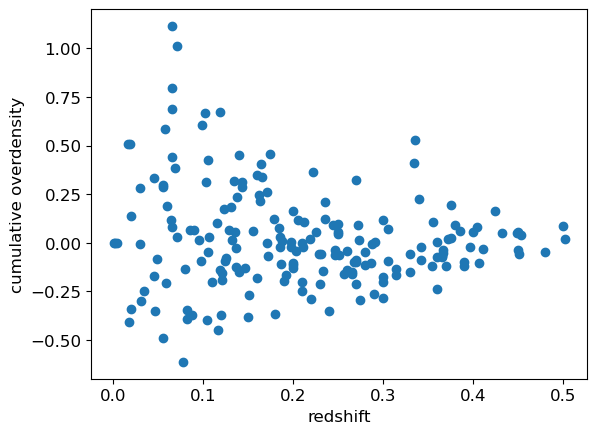

In [87]:
plt.scatter(ns_catalog["z"], ns_catalog["mapval"])
plt.xlabel("redshift")
plt.ylabel("cumulative overdensity")

In [88]:
extreme_sorted = ns_extr.sort_values("mapval")
extreme_sorted

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,mapclass,mappix,zweight,mapval
239,4FGL J1904.1+3627,286.034,36.453,3,4,0,1.85±0.06,0.078,BLL,E,2,3,40086,0.10,-0.613474
162,1ES 1727+502,262.078,50.227,5,11,4,1.785±0.022,0.055,BLL,E,0,2,22995,0.07,-0.491899
181,MG2 J204208+2426,310.536,24.458,4,5,1,1.947±0.052,0.104,BLL,E,0,4,57529,0.14,-0.397815
79,PKS 0352-686,58.274,-68.528,2,5,0,1.67±0.07,0.088,BLL,E,2,3,189801,0.10,-0.374470
61,GB6 J0442+6140,70.678,61.705,2,2,0,1.96±0.08,0.180,BLL,E,3,5,11764,0.18,-0.368308
10,B3 0037+405,10.099,40.836,1,3,1,1.88±0.11,0.240,BLL,E,3,6,33550,0.40,-0.350866
157,Markarian 501,253.474,39.759,81,109,22,1.795±0.008,0.034,BLL,E,0,1,35944,0.04,-0.247766
31,RBS 0413,49.972,18.753,3,7,1,1.709±0.054,0.190,BLL,E,0,6,66887,0.40,-0.199316
242,PMN J1911-1908,287.868,-19.149,2,4,0,1.87±0.07,0.160,BLL,E,2,5,130713,0.18,-0.179629
47,RBS 0351,41.158,-58.326,5,6,0,1.72±0.04,0.265,BLL,E,2,6,181683,0.40,-0.159155


## What is expected overdensity value?

Despite we know that AVERAGE overdensity of the map is 0, it DOES NOT mean that if we randomly scatter sources in the sky, we will get overall 0 overdensity value (becase overdensity is distributed approximately by Cauchy)

In [89]:
from scipy.ndimage import gaussian_filter1d

z_bins = np.linspace(0.01, 0.54, 50)

z = np.array(ns_catalog["z"])
hist, edges = np.histogram(np.log10(z), bins=50, density=True)
z_centers = 0.5 * (edges[1:] + edges[:-1])

# smooth
nz = gaussian_filter1d(hist, sigma=1.0)

# normalize
nz /= np.trapz(nz, z_centers)

# GENERATE A RANDOM SOURCE FIELD 
N_rand = 200 * ns_catalog.z.size
print(ns_catalog.z.size)

cdf = np.cumsum(nz)
cdf /= cdf[-1]

def sample_z(N):
    u = np.random.rand(N)
    return np.interp(u, cdf, z_centers)

z_rand = 10**sample_z(N_rand)

190


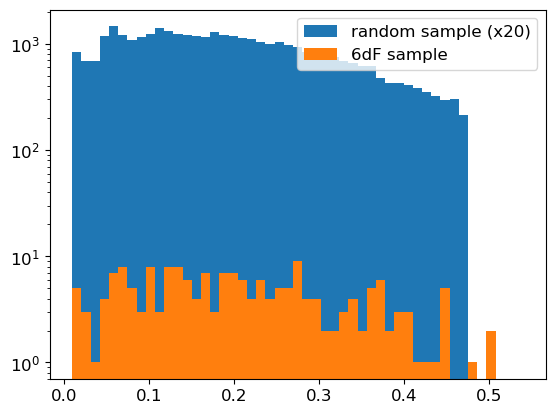

In [90]:
plt.hist(z_rand, bins=z_bins, label='random sample (x20)')
plt.hist(ns_catalog.z, bins=z_bins, label='6dF sample')
plt.legend()
plt.yscale('log')

In [91]:
# distributing random sources in the sky

mask = np.load('./2mass/2mass_mask.npy')

prob = mask.astype(float)
prob /= prob.sum()   # normalize

# draw pixel indices
npix = len(mask)
pix_rand = np.random.choice(np.arange(npix), size=N_rand, p=prob)

# convert to angles
theta_rand, phi_rand = hp.pix2ang(nside, pix_rand)

# to ra-dec
ra_rand = np.rad2deg(phi_rand)
dec_rand = 90 - np.rad2deg(theta_rand)

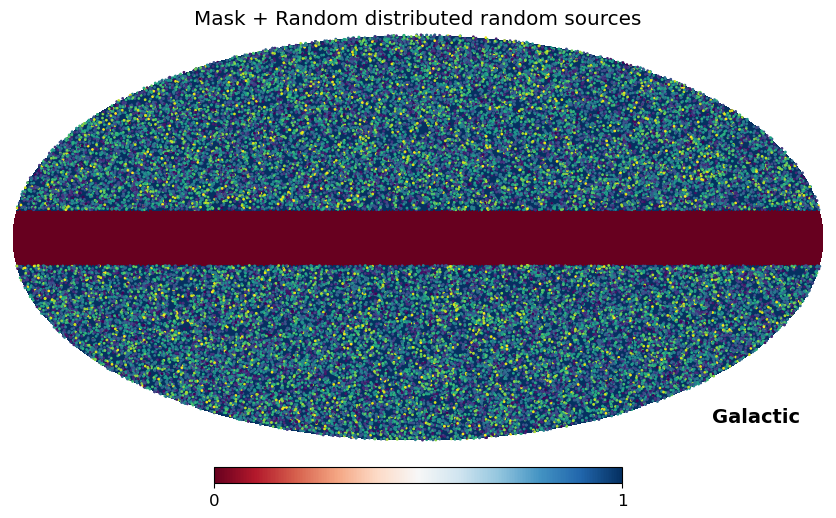

In [92]:
# sanity check of the randomly distributed sources
hp.mollview(mask, title="Mask + Random distributed random sources", rot=(180, 0, 0), cmap='RdBu', coord=['C', 'G'])
hp.projscatter(theta_rand, phi_rand, s=1, c=z_rand, coord='C')
plt.show()

In [93]:
rand_cat = pd.DataFrame(np.array([ra_rand, theta_rand, z_rand]).T, columns=["RA", "Dec", "z"])
rand_cat.head()

,RA,Dec,z
0,13.359375,1.450716,0.129261
1,268.636364,2.930699,0.211288
2,44.648437,1.186400,0.016866
3,7.382812,1.759413,0.317738
4,307.265625,0.411138,0.282157


In [94]:
# Map pix
rand_cat["mappix"] = pix_rand
rand_cat["mapclass"] = np.digitize(rand_cat["z"], zbins, right=True)
rand_cat.head()

,RA,Dec,z,mappix,mapclass
0,13.359375,1.450716,0.129261,86291,4
1,268.636364,2.930699,0.211288,194462,6
2,44.648437,1.186400,0.016866,61247,1
3,7.382812,1.759413,0.317738,116490,6
4,307.265625,0.411138,0.282157,8282,6


In [95]:
print(weights)
print(cs_weights)

rand_cat["zweight"] = 1.0
rand_cat["mapval"] = 0.0

for i in range(len(z_end)):
    good_src  = rand_cat["mapclass"] > i
    mapvals = maps[i][rand_cat["mappix"]]
    rand_cat["mapval"] += mapvals * good_src * weights[i]
    rand_cat.loc[good_src, "zweight"] = cs_weights[i]

# normalization
rand_cat["mapval"] /= rand_cat["zweight"]
rand_cat.head()

[0.03 0.03 0.03 0.04 0.04 0.  ]
[0.04, 0.07, 0.1, 0.14, 0.18, 0.4]


,RA,Dec,z,mappix,mapclass,zweight,mapval
0,13.359375,1.450716,0.129261,86291,4,0.14,-0.263610
1,268.636364,2.930699,0.211288,194462,6,0.40,-0.058062
2,44.648437,1.186400,0.016866,61247,1,0.04,-0.603550
3,7.382812,1.759413,0.317738,116490,6,0.40,0.002430
4,307.265625,0.411138,0.282157,8282,6,0.40,0.180254


RANDOM: -0.02699147868100544, DATA: 0.020927236645924798


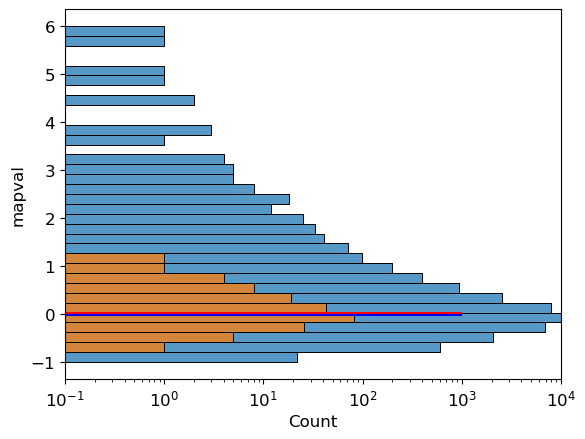

In [96]:
bins = np.linspace(-1, 6, 35, endpoint=True)

sns.histplot(y=rand_cat["mapval"], bins=bins)

sns.histplot(y=ns_catalog["mapval"], bins=bins)

m_r = np.average(rand_cat['mapval'])
m_d = np.average(ns_catalog['mapval'])

print(f"RANDOM: {m_r}, DATA: {m_d}")

plt.hlines([m_r, m_d], 0.1, 1000, colors=['blue', 'red'])

plt.xlim(0.1, 1e4)
plt.xscale('log')
plt.show()

### Bootstrapping mean value distribution

In [97]:
n_size = ns_catalog["z"].size
n = 0

means = []
while n < rand_cat["z"].size:
    rand_cat_i = rand_cat[n:n+n_size]
    means.append(np.average(rand_cat_i["mapval"]))
    n += n_size

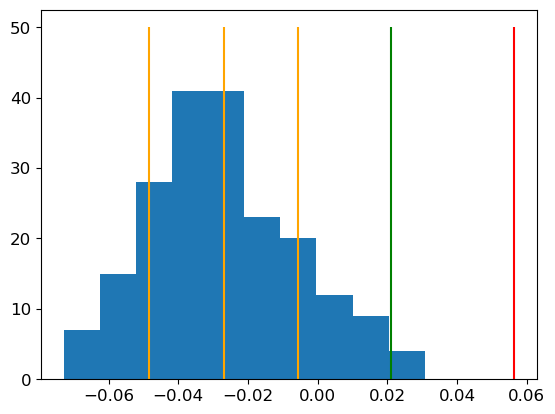

In [98]:
plt.hist(means)
plt.vlines([np.average(means), np.average(means) + np.std(means), np.average(means) - np.std(means)], 0, 50, color='orange')
plt.vlines([np.average(ns_catalog["mapval"]), np.average(ns_extr["mapval"])], 0, 50, colors=['green', 'red'])